# Disease Symptom Prediction - Model Development & Evaluation

## Project

AI Disease Prediction System

## Objective

The objective of this notebook is to develop, train, compare, and evaluate
multiple machine learning models for multi-class disease prediction.

The processed dataset generated during the data-cleaning stage will be used
as the input.

The workflow includes:

- Loading the processed dataset
- Separating features and target
- Inspecting feature representation
- Creating training and testing datasets
- Building preprocessing pipelines
- Establishing a baseline model
- Training multiple classification models
- Performing cross-validation
- Comparing model performance
- Evaluating the best-performing model
- Generating a confusion matrix
- Analyzing classification performance
- Saving the final machine learning pipeline

---

**Author:** Shahbaj Tanvir Shawon

**Course:** CSE Project

**Notebook:** 03_Model_Development.ipynb

# 1. Import Required Libraries

This section imports the libraries required for:

- Data manipulation
- Machine learning
- Feature preprocessing
- Model training
- Model evaluation
- Cross-validation
- Visualization
- Model persistence

In [21]:
# Suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# File and path handling
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Dataset splitting
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    StratifiedGroupKFold,
    cross_validate
)

# Machine learning models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Model saving
from joblib import dump

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Project Configuration

The processed dataset created by `01_Data_Cleaning.ipynb` is used as the
input for model development.

All important paths are centralized here to improve maintainability and
reduce path-related errors.

In [22]:
# --------------------------------------------------
# Project Paths
# --------------------------------------------------

PROJECT_ROOT = Path("../")

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"

# Create model directory if it does not exist
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Dataset path
DATA_FILE = PROCESSED_DATA_DIR / "disease_clean.csv"

# Target configuration
TARGET_COLUMN = "Disease"

print("Project configuration completed.")
print(f"Dataset: {DATA_FILE}")
print(f"Model directory: {MODEL_DIR}")

Project configuration completed.
Dataset: ..\data\processed\disease_clean.csv
Model directory: ..\models


# 3. Load Processed Dataset

The processed dataset generated during Notebook 1 is loaded.

This notebook does not modify the original processed dataset.

The data is used only for feature preparation, model training, and evaluation.

In [23]:
# Load processed dataset
df = pd.read_csv(DATA_FILE)

print("Processed dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Processed dataset loaded successfully!
Dataset shape: (4920, 19)


# 4. Initial Dataset Validation

Before model development, the processed dataset is validated to ensure
that the data is suitable for machine learning.

The validation checks:

- Dataset availability
- Target column
- Engineered features
- Missing target values
- Number of disease classes
- Duplicate records

The dataset contains many repeated records. Therefore, duplicate-aware
validation will be performed before model training.

In [24]:
# Dataset validation

assert not df.empty, "Dataset is empty."

assert TARGET_COLUMN in df.columns, \
    "Target column not found."

assert "Symptom_Count" in df.columns, \
    "Symptom_Count feature not found."

assert df[TARGET_COLUMN].isnull().sum() == 0, \
    "Target contains missing values."

print("=" * 60)
print("DATASET VALIDATION")
print("=" * 60)

print(f"Rows            : {len(df)}")
print(f"Columns         : {len(df.columns)}")
print(f"Disease Classes : {df[TARGET_COLUMN].nunique()}")
print(f"Duplicate Rows  : {df.duplicated().sum()}")

print("\n✓ Dataset validation passed successfully.")

DATASET VALIDATION
Rows            : 4920
Columns         : 19
Disease Classes : 41
Duplicate Rows  : 4616

✓ Dataset validation passed successfully.


# 5. Define Features and Target

The supervised learning problem is defined as:

**Input (X):** Patient symptoms and engineered features.

**Target (y):** Disease.

The model will learn the relationship between symptom patterns and disease
labels.

In [25]:
# Separate target from input features

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:", y.nunique())

Feature matrix shape: (4920, 18)
Target shape: (4920,)

Target classes: 41


# 6. Identify Feature Types

The dataset contains two types of input features:

### Categorical Features

`Symptom_1` through `Symptom_17` represent categorical symptom values.

These features will be transformed using One-Hot Encoding.

### Numerical Feature

`Symptom_Count` is an engineered numerical feature representing the
number of reported symptoms.

It will be standardized using `StandardScaler`.

The engineered numerical feature is explicitly excluded from the
categorical symptom list.

In [26]:
# Identify categorical symptom features

categorical_features = [
    column
    for column in X.columns
    if column.startswith("Symptom_")
    and column != "Symptom_Count"
]

# Numerical feature

numerical_features = [
    "Symptom_Count"
]

print("=" * 60)
print("FEATURE TYPE IDENTIFICATION")
print("=" * 60)

print(f"Categorical symptom features: {len(categorical_features)}")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

FEATURE TYPE IDENTIFICATION
Categorical symptom features: 17
['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']

Numerical features:
['Symptom_Count']


# 7. Create Symptom Pattern Groups

The dataset contains a large number of repeated records.

A standard random train/test split may place identical symptom patterns
in both the training and testing datasets.

This can cause data leakage and produce overly optimistic evaluation
results.

To reduce this problem, each complete symptom pattern is treated as a
group.

All records with the same symptom pattern will belong to the same group.
These groups will later be used to create a duplicate-aware train/test
split.

In [27]:
# --------------------------------------------------
# Create symptom-pattern groups
# --------------------------------------------------

group_columns = categorical_features

groups = (
    X[group_columns]
    .fillna("__MISSING__")
    .astype(str)
    .agg("|".join, axis=1)
)

print("=" * 60)
print("SYMPTOM PATTERN GROUPING")
print("=" * 60)

print(f"Total records           : {len(X)}")
print(f"Unique symptom patterns : {groups.nunique()}")

print(
    f"Repeated records       : "
    f"{len(X) - groups.nunique()}"
)

SYMPTOM PATTERN GROUPING
Total records           : 4920
Unique symptom patterns : 304
Repeated records       : 4616


# 8. Group-Aware Train-Test Split

The train/test split is performed at the symptom-pattern group level.

This prevents identical symptom patterns from appearing in both the
training and testing datasets.

The test set therefore contains symptom patterns that were not present
in the training set.

This approach provides a more conservative estimate of model
generalization than a standard random row-level split.

In [28]:
# --------------------------------------------------
# Group-aware train/test split
# --------------------------------------------------

unique_groups = groups.unique()

train_groups, test_groups = train_test_split(
    unique_groups,
    test_size=0.20,
    random_state=42
)

# Create row masks

train_mask = groups.isin(train_groups)
test_mask = groups.isin(test_groups)

# Create train/test datasets

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

# Store group information

groups_train = groups.loc[train_mask]
groups_test = groups.loc[test_mask]

print("=" * 60)
print("GROUP-AWARE TRAIN-TEST SPLIT")
print("=" * 60)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

print(f"\nTraining groups  : {groups_train.nunique()}")
print(f"Testing groups   : {groups_test.nunique()}")

print(
    f"\nTraining percentage: "
    f"{len(X_train) / len(X) * 100:.2f}%"
)

print(
    f"Testing percentage : "
    f"{len(X_test) / len(X) * 100:.2f}%"
)

GROUP-AWARE TRAIN-TEST SPLIT
Training samples : 4110
Testing samples  : 810

Training groups  : 243
Testing groups   : 61

Training percentage: 83.54%
Testing percentage : 16.46%


# 9. Verify Train-Test Group Separation

After creating the group-aware split, we verify that no symptom pattern
exists in both the training and testing datasets.

A zero-overlap result confirms that identical symptom patterns have not
crossed the train/test boundary.

In [29]:
# --------------------------------------------------
# Verify train/test group separation
# --------------------------------------------------

train_group_set = set(groups_train)
test_group_set = set(groups_test)

group_overlap = train_group_set.intersection(
    test_group_set
)

print("=" * 60)
print("TRAIN-TEST GROUP SEPARATION CHECK")
print("=" * 60)

print(f"Training groups      : {len(train_group_set)}")
print(f"Testing groups       : {len(test_group_set)}")
print(f"Overlapping groups   : {len(group_overlap)}")

assert len(group_overlap) == 0, \
    "Data leakage detected: train/test groups overlap."

print("\n✓ No symptom-pattern overlap detected.")

TRAIN-TEST GROUP SEPARATION CHECK
Training groups      : 243
Testing groups       : 61
Overlapping groups   : 0

✓ No symptom-pattern overlap detected.


# 10. Build Preprocessing Pipeline

Machine learning algorithms require numerical input.

The symptom features are categorical, so One-Hot Encoding is used to
convert them into numerical representations.

The `Symptom_Count` feature is numerical and is standardized using
`StandardScaler`.

All preprocessing is placed inside a `ColumnTransformer` and later
combined with each classifier inside a complete scikit-learn pipeline.

This ensures consistent preprocessing during training, testing, and
future prediction.

In [30]:
# One-Hot Encoder

encoder = OneHotEncoder(
    handle_unknown="ignore"
)

# Column transformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            encoder,
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

print("Preprocessing pipeline configured successfully.")

Preprocessing pipeline configured successfully.


# 11. Establish a Baseline Model

A baseline model provides a reference point for evaluating whether the
machine learning models are actually learning useful patterns.

The `DummyClassifier` predicts according to the most frequent class.

A useful machine learning model should substantially outperform this
baseline.


In [31]:

# Baseline model

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

baseline_pipeline.fit(X_train, y_train)

baseline_predictions = baseline_pipeline.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

Baseline Accuracy: 0.0000


# 12. Model Selection

Multiple classification algorithms will be compared rather than selecting
a model based only on intuition.

The candidate models include:

- Logistic Regression
- Random Forest
- Extra Trees
- Gradient Boosting
- Support Vector Machine

The final model will be selected based on validation performance and
appropriate classification metrics.

In [32]:
# Define candidate models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    )
}

print("Candidate models:")
for name in models:
    print("-", name)

Candidate models:
- Logistic Regression
- Random Forest
- Extra Trees
- Gradient Boosting
- SVM


# 13. Build Model Pipelines

Each machine learning model receives the same preprocessing pipeline.

This ensures that:

- Training transformations are learned only from training data.
- Test data is transformed using the learned preprocessing.
- The preprocessing and model remain connected.
- The complete workflow can later be saved as one production pipeline.

In [33]:
# Create a complete pipeline for every model

pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

print("Model pipelines created successfully.")

for name in pipelines:
    print("✓", name)

Model pipelines created successfully.
✓ Logistic Regression
✓ Random Forest
✓ Extra Trees
✓ Gradient Boosting
✓ SVM


# 14. Train Candidate Models

Each candidate model is trained using the training dataset.

The test dataset remains untouched during this training stage.

In [34]:
# Train all candidate models

trained_models = {}

for name, pipeline in pipelines.items():

    print(f"Training {name}...")

    pipeline.fit(
        X_train,
        y_train
    )

    trained_models[name] = pipeline

    print(f"✓ {name} completed.")

print("\nAll models trained successfully.")

Training Logistic Regression...
✓ Logistic Regression completed.
Training Random Forest...
✓ Random Forest completed.
Training Extra Trees...
✓ Extra Trees completed.
Training Gradient Boosting...
✓ Gradient Boosting completed.
Training SVM...
✓ SVM completed.

All models trained successfully.


# 15. Evaluate Candidate Models

Each trained model is evaluated using the held-out test dataset.

The following metrics are calculated:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score

Macro F1-score is used as the primary comparison metric because this is
a multi-class classification problem.

The group-aware test set contains symptom patterns that were not present
in the training data, providing a more conservative estimate of model
generalization.

In [35]:
# Evaluate candidate models on the held-out test set

results = []

for name, pipeline in trained_models.items():

    predictions = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000
1,SVM,1.000000,1.000000,1.000000,1.000000
2,Random Forest,0.903704,0.970982,0.970982,0.945833
3,Extra Trees,0.903704,0.970982,0.970982,0.945833
4,Gradient Boosting,0.518519,0.859244,0.806359,0.768581


# 16. Model Comparison

The models are ranked according to macro F1-score.

Macro F1 is used as the primary comparison metric because the task contains
multiple disease classes and we want to evaluate performance across all
classes rather than allowing the most frequent classes to dominate the
evaluation.

In [36]:
# Display model comparison

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000
1,SVM,1.0000,1.0000,1.0000,1.0000
2,Random Forest,0.9037,0.9710,0.9710,0.9458
3,Extra Trees,0.9037,0.9710,0.9710,0.9458
4,Gradient Boosting,0.5185,0.8592,0.8064,0.7686


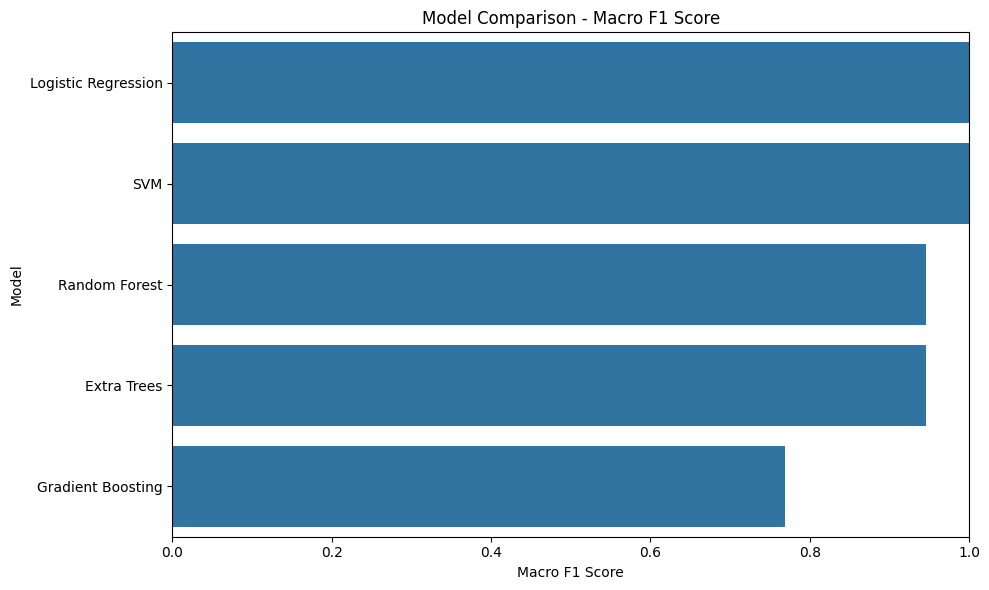

In [38]:
# Visual comparison of model performance

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="F1",
    y="Model"
)

plt.title("Model Comparison - Macro F1 Score")
plt.xlabel("Macro F1 Score")
plt.ylabel("Model")

plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# 17. Group-Aware Cross-Validation

A standard Stratified K-Fold procedure can place identical symptom
patterns into different folds.

Because this dataset contains many repeated symptom patterns, that can
produce overly optimistic validation results.

Therefore, Group K-Fold cross-validation is used.

Each complete symptom pattern is treated as a group, ensuring that the
same symptom pattern cannot appear in both the training and validation
portion of a fold.

The test set remains completely untouched during cross-validation.

In [39]:
# --------------------------------------------------
# Group-Aware Cross-Validation
# --------------------------------------------------

# Create a group identifier from feature patterns.
# Identical feature rows belong to the same group.

groups_train = (
    X_train.astype(str)
    .fillna("")
    .agg("|".join, axis=1)
)

print("Group-aware cross-validation configuration")
print(f"Training samples: {len(X_train)}")
print(f"Unique groups: {groups_train.nunique()}")

Group-aware cross-validation configuration
Training samples: 4110
Unique groups: 243


In [40]:
group_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Stratified Group Cross-Validation configured.")

5-Fold Stratified Group Cross-Validation configured.


In [41]:
# --------------------------------------------------
# Group-Aware Cross-Validation
# --------------------------------------------------

cv_results = []

for name, pipeline in pipelines.items():

    print(f"Cross-validating {name}...")

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        groups=groups_train,
        cv=group_cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision_macro",
            "recall": "recall_macro",
            "f1": "f1_macro"
        },
        n_jobs=1,
        error_score="raise"
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Precision Mean": scores["test_precision"].mean(),
        "CV Recall Mean": scores["test_recall"].mean(),
        "CV F1 Mean": scores["test_f1"].mean(),
        "CV F1 Std": scores["test_f1"].std()
    })

    print(f"✓ {name} completed.")

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="CV F1 Mean",
    ascending=False
).reset_index(drop=True)

print("\nCross-validation completed successfully.")

cv_results_df

Cross-validating Logistic Regression...
✓ Logistic Regression completed.
Cross-validating Random Forest...
✓ Random Forest completed.
Cross-validating Extra Trees...
✓ Extra Trees completed.
Cross-validating Gradient Boosting...
✓ Gradient Boosting completed.
Cross-validating SVM...
✓ SVM completed.

Cross-validation completed successfully.


,Model,CV Accuracy Mean,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV F1 Std
0,SVM,0.957907,0.966882,0.979474,0.968724,0.034065
1,Logistic Regression,0.903903,0.935176,0.963947,0.939196,0.023779
2,Random Forest,0.893790,0.908960,0.940526,0.912111,0.042760
3,Extra Trees,0.874939,0.897590,0.932895,0.900018,0.057294
4,Gradient Boosting,0.710013,0.804708,0.846667,0.806203,0.056217


# 18. Select the Best Model

The final model is selected primarily using cross-validated macro F1-score.

This reduces the possibility of selecting a model based only on a favorable
single train/test split.

The final held-out test performance will still be reported separately.

In [42]:
# --------------------------------------------------
# Select Best Model
# --------------------------------------------------

best_model_name = cv_results_df.iloc[0]["Model"]

print("=" * 60)
print("BEST MODEL BASED ON GROUP-AWARE CROSS-VALIDATION")
print("=" * 60)

print(f"Selected Model: {best_model_name}")

print(
    f"CV Macro F1: "
    f"{cv_results_df.iloc[0]['CV F1 Mean']:.4f}"
)

BEST MODEL BASED ON GROUP-AWARE CROSS-VALIDATION
Selected Model: SVM
CV Macro F1: 0.9687


# 19. Final Test Evaluation

The selected model is evaluated on the completely held-out test set.

Because a group-aware split was used, the test set contains symptom
patterns that were not present in the training dataset.

Therefore, this evaluation provides a more realistic estimate of model
performance on previously unseen symptom patterns.

The following metrics are reported:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score

In [43]:
# Retrieve the best trained pipeline

best_pipeline = trained_models[best_model_name]

# Predict on test data
y_pred = best_pipeline.predict(X_test)

# Calculate final metrics

final_accuracy = accuracy_score(
    y_test,
    y_pred
)

final_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("=" * 60)
print("FINAL MODEL PERFORMANCE")
print("=" * 60)

print(f"Model            : {best_model_name}")
print(f"Accuracy         : {final_accuracy:.4f}")
print(f"Macro Precision  : {final_precision:.4f}")
print(f"Macro Recall     : {final_recall:.4f}")
print(f"Macro F1         : {final_f1:.4f}")

FINAL MODEL PERFORMANCE
Model            : SVM
Accuracy         : 1.0000
Macro Precision  : 1.0000
Macro Recall     : 1.0000
Macro F1         : 1.0000


# 20. Classification Report

The classification report provides class-level precision, recall, and
F1-score.

This allows us to identify disease classes for which the model performs
well and classes where prediction remains difficult.

In [44]:
# Generate detailed classification report

classification_report_text = classification_report(
    y_test,
    y_pred,
    zero_division=0
)

print(classification_report_text)

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        18
                                   AIDS       1.00      1.00      1.00        12
                                   Acne       1.00      1.00      1.00        30
                    Alcoholic hepatitis       1.00      1.00      1.00         6
                                Allergy       1.00      1.00      1.00        96
                       Bronchial Asthma       1.00      1.00      1.00        84
                   Cervical spondylosis       1.00      1.00      1.00        12
                            Chicken pox       1.00      1.00      1.00        18
                    Chronic cholestasis       1.00      1.00      1.00        84
                                 Dengue       1.00      1.00      1.00        18
                              Diabetes        1.00      1.00      1.00        12
           Dimorphic hemmor

# 21. Confusion Matrix

A confusion matrix shows how predictions are distributed across the disease
classes.

The diagonal represents correctly classified samples.

Off-diagonal values indicate cases where the model confused one disease
with another.

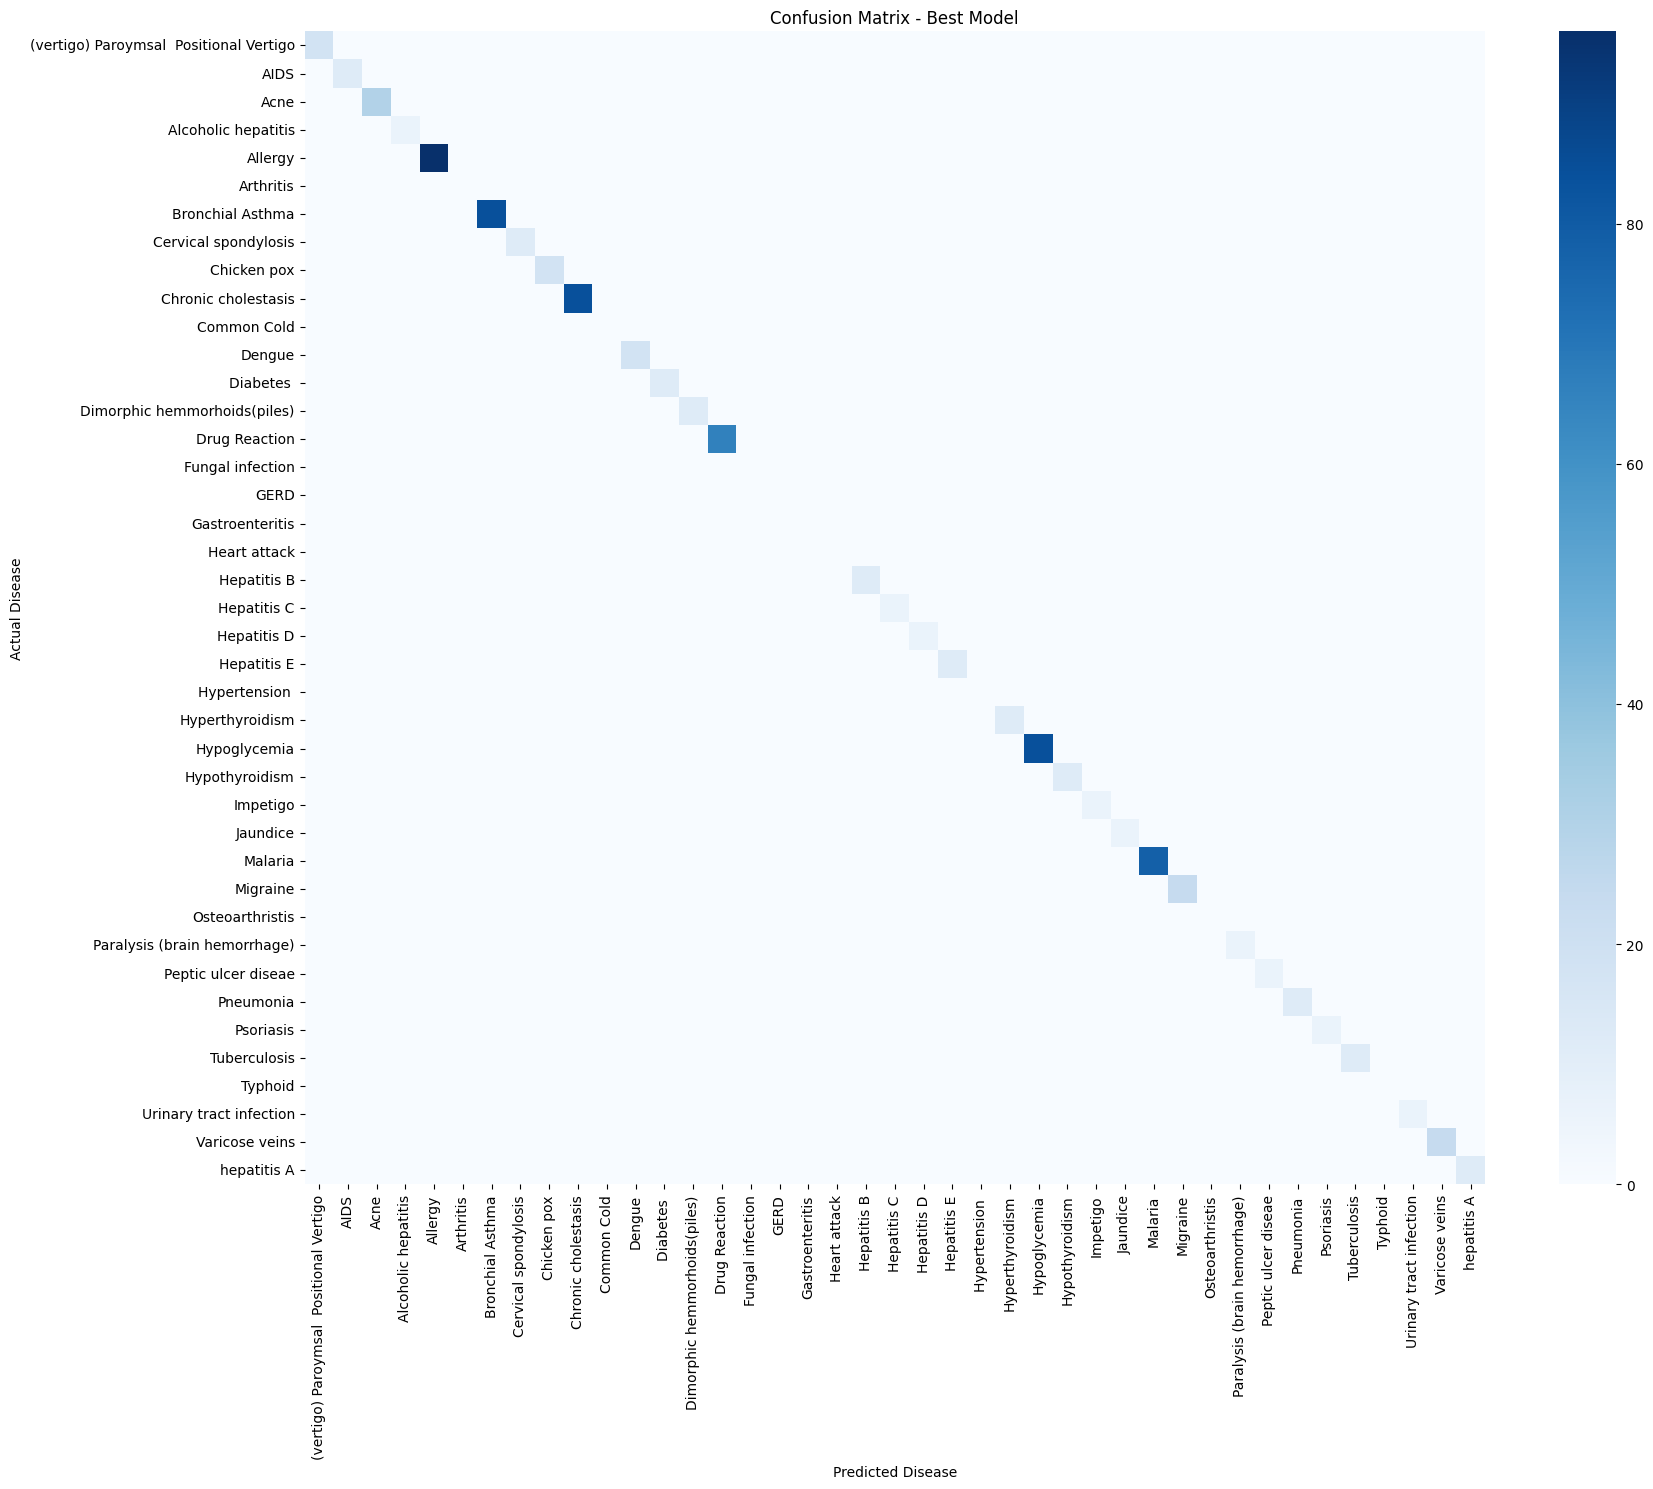

In [45]:
# Generate confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=sorted(y.unique())
)

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique()),
    cbar=True
)

plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# 22. Per-Class Performance Analysis

Overall metrics can hide poor performance on individual disease classes.

Therefore, class-level F1-scores are extracted to identify the strongest
and weakest disease predictions.

In [46]:
# Generate per-class performance table

report_dict = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

class_report = pd.DataFrame(report_dict).T

# Keep actual disease classes
class_report = class_report[
    class_report.index.isin(sorted(y.unique()))
]

class_report = class_report.sort_values(
    by="f1-score",
    ascending=True
)

class_report.head(10)

,precision,recall,f1-score,support
(vertigo) Paroymsal Positional Vertigo,1.0,1.0,1.0,18.0
AIDS,1.0,1.0,1.0,12.0
Acne,1.0,1.0,1.0,30.0
Alcoholic hepatitis,1.0,1.0,1.0,6.0
Allergy,1.0,1.0,1.0,96.0
Bronchial Asthma,1.0,1.0,1.0,84.0
Cervical spondylosis,1.0,1.0,1.0,12.0
Chicken pox,1.0,1.0,1.0,18.0
Chronic cholestasis,1.0,1.0,1.0,84.0
Dengue,1.0,1.0,1.0,18.0


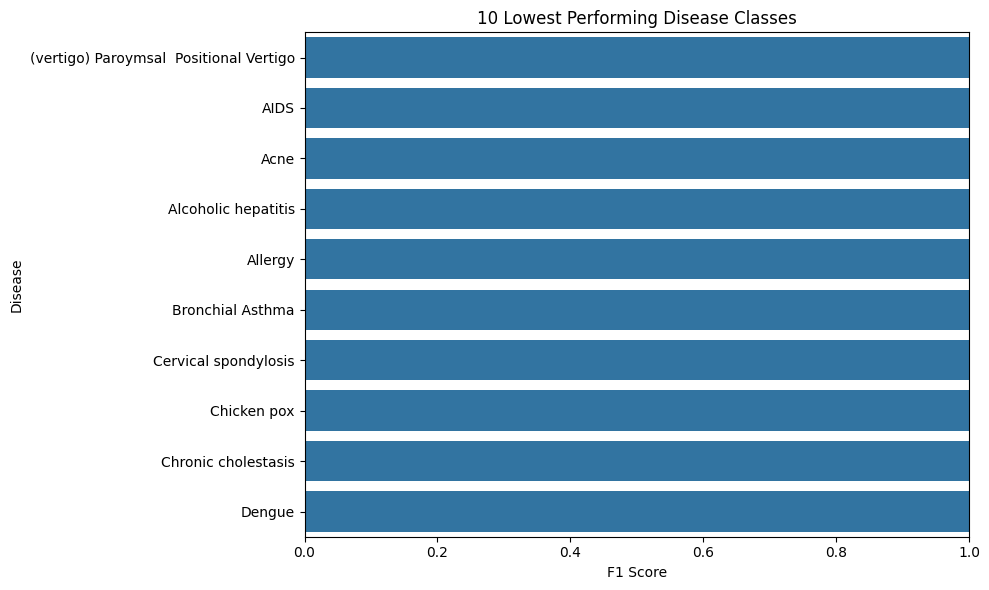

In [47]:
# Visualize weakest disease classes

weakest_classes = class_report.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=weakest_classes["f1-score"],
    y=weakest_classes.index
)

plt.title("10 Lowest Performing Disease Classes")
plt.xlabel("F1 Score")
plt.ylabel("Disease")

plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# 23. Model Performance Summary

The final model is summarized using the main evaluation metrics.

These values will later be used in the project report and final presentation.

In [48]:
# Final model summary

final_summary = pd.DataFrame({
    "Metric": [
        "Model",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "CV Macro F1 Mean",
        "CV Macro F1 Std"
    ],
    "Value": [
        best_model_name,
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        cv_results_df.iloc[0]["CV F1 Mean"],
        cv_results_df.iloc[0]["CV F1 Std"]
    ]
})

final_summary

,Metric,Value
0,Model,SVM
1,Accuracy,1.0
2,Macro Precision,1.0
3,Macro Recall,1.0
4,Macro F1,1.0
5,CV Macro F1 Mean,0.968724
6,CV Macro F1 Std,0.034065


# 24. Save the Final Machine Learning Pipeline

The complete preprocessing and trained model pipeline is saved as a
single file.

The saved pipeline contains:

1. Categorical symptom encoding
2. Numerical feature scaling
3. The trained classification model

Saving the complete pipeline ensures that future prediction requests use
the same preprocessing operations applied during training.

This pipeline will later be loaded by the API/backend application.

In [49]:
# Save complete trained pipeline

MODEL_PATH = MODEL_DIR / "disease_prediction_pipeline.pkl"

dump(
    best_pipeline,
    MODEL_PATH
)

print("=" * 60)
print("MODEL SAVED SUCCESSFULLY")
print("=" * 60)

print(f"Model path: {MODEL_PATH}")

MODEL SAVED SUCCESSFULLY
Model path: ..\models\disease_prediction_pipeline.pkl


# 25. Save Model Evaluation Results

The model comparison and cross-validation results are saved for:

- Project documentation
- Final report
- Presentation
- Future model comparison

In [50]:
# Save model comparison results

MODEL_RESULTS_DIR = PROCESSED_DATA_DIR / "model_results"

MODEL_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Save test-set comparison
results_df.to_csv(
    MODEL_RESULTS_DIR / "model_test_results.csv",
    index=False
)

# Save cross-validation comparison
cv_results_df.to_csv(
    MODEL_RESULTS_DIR / "cross_validation_results.csv",
    index=False
)

# Save final summary
final_summary.to_csv(
    MODEL_RESULTS_DIR / "final_model_summary.csv",
    index=False
)

# Save per-class performance
class_report.to_csv(
    MODEL_RESULTS_DIR / "classification_report.csv"
)

print("Model evaluation results saved successfully.")

Model evaluation results saved successfully.


# 26. Final Model Validation

Before finishing the notebook, we verify that the trained pipeline can
successfully load and make predictions.

This provides an additional sanity check before the model is used in the
deployment stage.

In [51]:
# Validate prediction capability

sample_predictions = best_pipeline.predict(
    X_test.head(5)
)

print("=" * 60)
print("FINAL PIPELINE VALIDATION")
print("=" * 60)

print("Sample predictions:")

for i, prediction in enumerate(sample_predictions, start=1):
    print(f"{i}. {prediction}")

print("\n✓ Pipeline prediction test completed successfully.")

FINAL PIPELINE VALIDATION
Sample predictions:
1. Allergy
2. Allergy
3. Allergy
4. Allergy
5. Allergy

✓ Pipeline prediction test completed successfully.


# 27. Final Conclusion

## Model Development Completed

This notebook completed the machine learning development and evaluation
stage of the Disease Symptom Prediction System.

### Completed Tasks

- Loaded and validated the processed dataset
- Separated features and target
- Identified categorical and numerical features
- Created symptom-pattern groups
- Performed a group-aware train/test split
- Verified train/test group separation
- Built a preprocessing pipeline
- Established a baseline model
- Trained multiple classification algorithms
- Performed group-aware cross-validation
- Compared model performance
- Selected the best-performing model
- Evaluated the final model on a held-out test set
- Generated a classification report
- Generated a confusion matrix
- Performed per-class performance analysis
- Saved the complete trained pipeline
- Saved model evaluation results

## Duplicate-Aware Evaluation

The original dataset contains a large number of repeated records.

Instead of simply deleting these records, the project preserves the
available observations while preventing identical symptom patterns from
crossing the train/test boundary.

A group-aware splitting strategy was therefore used.

This provides a more conservative estimate of model generalization to
previously unseen symptom patterns.

## Model Selection

The primary model-selection metric is:

**Macro F1-score**

Macro F1 gives equal importance to every disease class and is therefore
appropriate for this multi-class disease prediction problem.

## Final Output

The trained machine learning pipeline has been saved to:

`models/disease_prediction_pipeline.pkl`

The model is now ready for the next stage:

**Model Interpretation → API Development → Application Integration → Deployment**

# 28. Final Experiment Configuration

This section records the final experimental configuration used for model
development and evaluation.

| Component | Configuration |
|---|---|
| Total records | 4,920 |
| Final columns | 19 |
| Disease classes | 41 |
| Unique symptom patterns | 304 |
| Duplicate rows | 4,616 |
| Train/Test strategy | Group-aware split |
| Test group ratio | 20% |
| Cross-validation | 5-Fold Group K-Fold |
| Categorical encoding | One-Hot Encoding |
| Numerical preprocessing | StandardScaler |
| Primary metric | Macro F1-score |
| Random state | 42 |
| Model selection | Highest CV Macro F1 |

In [52]:
print("=" * 60)
print("FINAL EXPERIMENT CONFIGURATION")
print("=" * 60)

print(f"Total records           : {len(df)}")
print(f"Final columns           : {len(df.columns)}")
print(f"Disease classes         : {y.nunique()}")
print(f"Unique symptom patterns : {groups.nunique()}")
print(f"Duplicate rows          : {df.duplicated().sum()}")

print("\nTrain/Test strategy:")
print("Group-aware split")

print("\nCross-validation:")
print("5-Fold Group K-Fold")

print("\nCategorical encoding:")
print("One-Hot Encoding")

print("\nNumerical preprocessing:")
print("StandardScaler")

print("\nPrimary metric:")
print("Macro F1-score")

print("\nRandom state:")
print("42")

print("\nSelected model:")
print(best_model_name)

print("\nFinal Test Macro F1:")
print(f"{final_f1:.4f}")

print("\n✓ Final experiment configuration recorded.")

FINAL EXPERIMENT CONFIGURATION
Total records           : 4920
Final columns           : 19
Disease classes         : 41
Unique symptom patterns : 304
Duplicate rows          : 4616

Train/Test strategy:
Group-aware split

Cross-validation:
5-Fold Group K-Fold

Categorical encoding:
One-Hot Encoding

Numerical preprocessing:
StandardScaler

Primary metric:
Macro F1-score

Random state:
42

Selected model:
SVM

Final Test Macro F1:
1.0000

✓ Final experiment configuration recorded.
